In [1]:
import random
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import Dataset, DatasetDict, load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline,
)

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)
pd.set_option("display.precision", 4)

In [2]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [3]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [4]:
full_ds = load_dataset('emotion')
full_ds

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [5]:
train_ds = full_ds["train"]
val_ds = full_ds["validation"]
test_ds = full_ds["test"]

class_names = train_ds.features["label"].names
n_classes = len(class_names)

In [6]:
print(f"train: {train_ds.shape}")
print(f"val: {val_ds.shape}")
print(f"test: {test_ds.shape}")
print()

print("Пример из train:")
display(train_ds[:3])

print("Пример из validation:")
display(val_ds[:3])

print(f'Классы: {class_names}')
print(f'Количество классов: {n_classes}')

train: (16000, 2)
val: (2000, 2)
test: (2000, 2)

Пример из train:


{'text': ['i didnt feel humiliated',
  'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
  'im grabbing a minute to post i feel greedy wrong'],
 'label': [0, 0, 3]}

Пример из validation:


{'text': ['im feeling quite sad and sorry for myself but ill snap out of it soon',
  'i feel like i am still looking at a blank canvas blank pieces of paper',
  'i feel like a faithful servant'],
 'label': [0, 0, 2]}

Классы: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Количество классов: 6


В данной работе англоязычные тексты из датасета "emotions" будут классифицироваться по эмоциям, которые с помощью них выражаются. Эти эмоции представлены шестью классами: sadness (грусть), joy (радость), love (любовь), anger (злость), fear (страх), surprise (удивление).

**Токенизация**

In [7]:
MODEL_NAME = "nlptown/bert-base-multilingual-uncased-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

sample_texts = test_ds[:3]["text"]

batch_no_trunc = tokenizer(
    sample_texts,
    padding=True,
    truncation=False,
    return_tensors='pt'
)

batch_with_trunc = tokenizer(
    sample_texts,
    padding=True,
    truncation=True,
    max_length=16,
    return_tensors='pt'
)

print('=' * 20 + 'ПРИМЕРЫ БЕЗ TRUNCATION' + '=' * 20)
for idx, text in enumerate(sample_texts):
    print(f'-----Пример {idx+1}-----')
    print(f'Text: {text}')
    print(f'Tokens: {tokenizer.convert_ids_to_tokens(batch_no_trunc['input_ids'][idx])}')
    print(f'Input ids: {batch_no_trunc['input_ids'][idx]}')
    print(f'Attention mask: {batch_no_trunc['attention_mask'][idx]}')
    print()

print('=' * 20 + 'ПРИМЕРЫ C TRUNCATION' + '=' * 20)
for idx, text in enumerate(sample_texts):
    print(f'-----Пример {idx+1}-----')
    print(f'Text: {text}')
    print(f'Tokens: {tokenizer.convert_ids_to_tokens(batch_with_trunc['input_ids'][idx])}')
    print(f'Input ids: {batch_with_trunc['input_ids'][idx]}')
    print(f'Attention mask: {batch_with_trunc['attention_mask'][idx]}')
    print()

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

====================ПРИМЕРЫ БЕЗ TRUNCATION====================
-----Пример 1-----
Text: im feeling rather rotten so im not very ambitious right now
Tokens: ['[CLS]', 'im', 'feeling', 'rather', 'rotten', 'so', 'im', 'not', 'very', 'ambit', '##ious', 'right', 'now', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
Input ids: tensor([  101, 10205, 35260, 16571, 30493, 10297, 10205, 10497, 12495, 93565,
        22173, 12873, 11628,   102,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0])
Attention mask: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0])

-----Пример 2-----
Text: im updating my blog because i feel shitty
Tokens: ['[CLS]', 'im', 'up', '##dati', '##ng', 'my', 'blog', 'because', 'i', 'feel', 'shi', '##tty', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[

In [8]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [9]:
demo_texts = train_ds['text'][:10]
pipeline_device = 0 if torch.cuda.is_available() else -1

text_clf = pipeline(
    task="text-classification",
    model=model,
    tokenizer=tokenizer,
    device=device
)

pipeline_outputs = text_clf(demo_texts)

pipeline_df = pd.DataFrame(
    {
        "text": demo_texts,
        "predicted_label": [item["label"] for item in pipeline_outputs],
        "score": [item["score"] for item in pipeline_outputs],
    }
)

pipeline_df

,text,predicted_label,score
0,i didnt feel humiliated,2 stars,0.3999
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,1 star,0.4637
2,im grabbing a minute to post i feel greedy wrong,1 star,0.6046
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,5 stars,0.5367
4,i am feeling grouchy,2 stars,0.3835
5,ive been feeling a little burdened lately wasnt sure why that was,3 stars,0.5304
6,ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny,4 stars,0.3484
7,i feel as confused about life as a teenager or as jaded as a year old man,2 stars,0.3925
8,i have been with petronas for years i feel that petronas has performed well and made a huge profit,5 stars,0.6509
9,i feel romantic too,5 stars,0.5279


Модель была обучена на тысячах отзывов для их классификации он негативных до позитивных. Но наша задача состоит в классификации эмоций, под эту задачу исходная предобученная модель не слишком подходит, поэтому требуется дообучение с заменой классификационной головы.

**Fine-tuning для классификации текста**

In [10]:
id2label = {idx: label for idx, label in enumerate(class_names)}
label2id = {label: idx for idx, label in id2label.items()}


model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    id2label=id2label,
    label2id=label2id,
    num_labels=n_classes,
    ignore_mismatched_sizes=True
)
model.to(device)

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128
    )

tok_train = train_ds.map(tokenize_batch, batched=True).remove_columns(['text'])
tok_val = val_ds.map(tokenize_batch, batched=True).remove_columns(['text'])
tok_test = test_ds.map(tokenize_batch, batched=True).remove_columns(['text'])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: nlptown/bert-base-multilingual-uncased-sentiment
Key               | Status   |                                                                                     
------------------+----------+-------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([5]) vs model:torch.Size([6])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([5, 768]) vs model:torch.Size([6, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [11]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }

In [12]:
common_training_kwargs = dict(
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=2,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
)

try:
    training_args = TrainingArguments(
        evaluation_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )
except TypeError:
    training_args = TrainingArguments(
        eval_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )

training_args

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

In [13]:
try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tok_train,
        eval_dataset=tok_val,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tok_train,
        eval_dataset=tok_val,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.033673,0.248663,0.924500,0.899016,0.925199
2,0.487040,0.189669,0.935500,0.906645,0.935217
3,0.040291,0.201886,0.937000,0.912471,0.937077


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=6000, training_loss=0.26869445494847605, metrics={'train_runtime': 772.4482, 'train_samples_per_second': 62.14, 'train_steps_per_second': 7.768, 'total_flos': 1083094445562048.0, 'train_loss': 0.26869445494847605, 'epoch': 3.0})

In [15]:
test_pred = trainer.predict(tok_test)
logits = test_pred.predictions
y_true = test_pred.label_ids
y_pred = np.argmax(logits, axis=-1)

test_metrics = compute_metrics((logits, y_true))
print("=== Финальная оценка на test ===")
for k, v in test_metrics.items():
    if isinstance(v, float):
        print(f"  eval_{k}: {v:.4f}")
    else:
        print(f"  eval_{k}: {v}")

test_acc = float(test_metrics["accuracy"])
test_f1m = float(test_metrics["f1_macro"])
test_f1w = float(test_metrics["f1_weighted"])
print()
print("accuracy:", f"{test_acc:.4f}")
print("f1_macro:", f"{test_f1m:.4f}")
print("f1_weighted:", f"{test_f1w:.4f}")

=== Финальная оценка на test ===
  eval_accuracy: 0.9255
  eval_f1_macro: 0.8778
  eval_f1_weighted: 0.9251

accuracy: 0.9255
f1_macro: 0.8778
f1_weighted: 0.9251


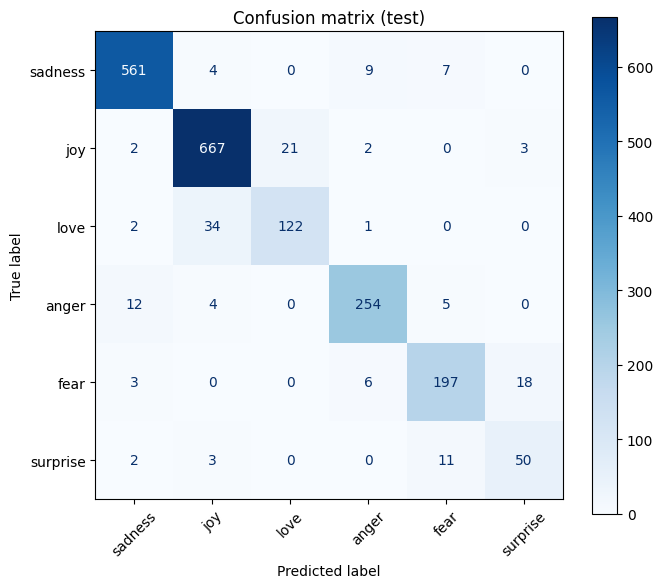

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=True)
ax.set_title("Confusion matrix (test)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
probs = torch.softmax(torch.tensor(logits, dtype=torch.float32), dim=-1).numpy()
confidences = probs.max(axis=1)

texts_test = test_ds["text"]
true_names = [class_names[i] for i in y_true]
pred_names = [class_names[i] for i in y_pred]

df_show = pd.DataFrame(
    {
        "text": texts_test,
        "true_label": true_names,
        "pred_label": pred_names,
        "confidence": confidences,
    }
)

print(df_show.head(10).to_string(index=False))

df_show.head(100).to_csv("sample_predictions.csv", index=False)

                                                                                                                                                                                                                          text true_label pred_label  confidence
                                                                                                                                                                   im feeling rather rotten so im not very ambitious right now    sadness    sadness      0.9995
                                                                                                                                                                                     im updating my blog because i feel shitty    sadness    sadness      0.9996
                                                                                                                             i never make her separate from me because i don t ever want her to feel like i m ashamed with her    sad

In [20]:
wrong = df_show[df_show["true_label"] != df_show["pred_label"]].copy()
wrong = wrong.sort_values("confidence", ascending=False)
print("Ошибки с высокой уверенностью:")
print(wrong.head(5).to_string(index=False))
print()
print("Пограничные (низкая уверенность):")
print(df_show.nsmallest(5, "confidence").to_string(index=False))

Ошибки с высокой уверенностью:
                                                                                                                                                                                                              text true_label pred_label  confidence
                                                                                                                                                                                     i feel cared for and accepted       love        joy      0.9994
                                                                                                                                            whenever i put myself in others shoes and try to make the person happy      anger        joy      0.9994
i feel inside cause life is like a game sometimes but then you came around me the walls just disappeared nothing to surround me and keep me from my fears im unprotected see how ive opened up youve made me trust       fear    sadness  